## Model Training

### Purpose
To use tf-idf feature engineering to convert raw data into meaningful machine inputs. The converted data is then used to train Naive Bayes and Logistic Regression models for sentiment classification of Covid-19 tweets in Nepali. 

### Input
- `covid19_cleaned_sentiments.csv` — output of `data_prep.ipynb`

### Output
- `saved_models/tfidf_u.pkl` — unigram TF-IDF vectoriser
- `saved_models/tfidf_ub.pkl` — bigram TF-IDF vectoriser
- `saved_models/nb_u.pkl`, `nb_ub.pkl` — trained Naive Bayes models
- `saved_models/lr_u.pkl`, `lr_ub.pkl` — trained Logistic Regression models
- `saved_models/test_data.csv` — test set for bias evaluation

### Sections
1. Feature Engineering — TF-IDF unigram and bigram
2. Model Training and Evaluation — NB and LR with performance metrics
3. Performance Comparison — visualised metric comparisons

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

## Feature Engineering

For feature engineering, the scikit learn library has been used. For this project, the TF-IDF (Term Frequency - Inverse Document Frequency) has been used for feature engineering. 

Although BoW (Bag of Words) method is also useful for sentiment classification, it only gives the model an overview of the frequency of occurrence of the word in a document. Because it uses word count, the most common words can receive more weightage even if they do not have much semantic weight as compared to other sentiment-heavy words. Moreover, the more frequently occurring words may be neutral and occur across positive and negative sentiments which is not very beneficial in a sentiment classification task. 

However, TF-IDF provides a better overview of the importance of a particular word in a corpus. It reduces the weight of the most common words while giving more weight to words that occur rarely, words that more often carry the sentimental weight of a particular sentence. 
$$
TF(t, d) = \frac{\text{count of term } t \text{ in document } d}{\text{total terms in } d}
$$

$$
IDF(t) = \log\left(\frac{N}{DF(t)}\right)
$$

$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$

A combination of two features are used for feature engineering: unigram and unigram + bigram. The unigram feature is the most simplistic where each word is treated independently. It will help in creating baseline models for both the Naive Bayes and Logistic Regression models. 

On the other hand, the unigram + bigram feature allows the model to capture context since sentiments often do not occur in isolation but through combinations of words. The unigram feature serves as a baseline to measure the performance of the unigram + bigram feature model and helps to understand how contextual information influences sentiment classification tasks. 

In [2]:
df = pd.read_csv('covid19_cleaned_sentiments.csv')

In [3]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(df['Sentences'],
                                                              df['Sentiment'], 
                                                              test_size=0.2,
                                                              random_state=42)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Feature engineering for baseline model
tfidf_u = TfidfVectorizer(ngram_range=(1,1), min_df=2)
X_train_u = tfidf_u.fit_transform(X_train_text)
X_test_u = tfidf_u.transform(X_test_text)

#Feature engineering for improved model with unigram + bigram features
tfidf_ub = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train_ub = tfidf_ub.fit_transform(X_train_text)
X_test_ub = tfidf_ub.transform(X_test_text)

## Training and Evaluation

### Naive Bayes

In [5]:
from sklearn.naive_bayes import MultinomialNB as mnb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Baseline NB model (Unigram)
nb_u = mnb()
nb_u.fit(X_train_u, y_train)
y_pred_u = nb_u.predict(X_test_u)

print('PERFORMANCE METRICS FOR BASELINE NB MODEL', '\n', '-'*39)
acc_u = accuracy_score(y_test, y_pred_u)
print(f'\nThe accuracy of the baseline NB model is {acc_u:.4f}')
prec_u = precision_score(y_test, y_pred_u)
print(f'The precision of the baseline NB model is {prec_u:.4f}')
rec_u= recall_score(y_test, y_pred_u)
print(f'The recall of the baseline NB model is {rec_u:.4f}')
f1_u_mic = f1_score(y_test, y_pred_u, average='micro')
f1_u_mac = f1_score(y_test, y_pred_u, average='macro')
print(f'The micro-averaged f1 score of the baseline NB model is {f1_u_mic:.4f}')
print(f'The micro-averaged f1 score of the baseline NB model is {f1_u_mac:.4f}')

PERFORMANCE METRICS FOR BASELINE NB MODEL 
 ---------------------------------------

The accuracy of the baseline NB model is 0.7399
The precision of the baseline NB model is 0.7110
The recall of the baseline NB model is 0.8412
The micro-averaged f1 score of the baseline NB model is 0.7399
The micro-averaged f1 score of the baseline NB model is 0.7351


In [6]:
#Improved NB model (Unigram + Bigram)

nb_ub = mnb()
nb_ub.fit(X_train_ub, y_train)
y_pred_ub = nb_ub.predict(X_test_ub)

print('PERFORMANCE METRICS FOR IMPROVED NB MODEL', '\n', '-'*39)
acc_ub = accuracy_score(y_test, y_pred_ub)
print(f'\nThe accuracy of the improved NB model is {acc_ub:.4f}')
prec_ub = precision_score(y_test, y_pred_ub)
print(f'The precision of the improved NB model is {prec_ub:.4f}')
rec_ub= recall_score(y_test, y_pred_ub)
print(f'The recall of the improved NB model is {rec_ub:.4f}')
f1_ub_mic = f1_score(y_test, y_pred_ub, average='micro')
f1_ub_mac = f1_score(y_test, y_pred_ub, average='macro')
print(f'The micro-averaged f1 score of the improved NB model is {f1_ub_mic:.4f}')
print(f'The micro-averaged f1 score of the improved NB model is {f1_ub_mac:.4f}')

PERFORMANCE METRICS FOR IMPROVED NB MODEL 
 ---------------------------------------

The accuracy of the improved NB model is 0.7707
The precision of the improved NB model is 0.7322
The recall of the improved NB model is 0.8807
The micro-averaged f1 score of the improved NB model is 0.7707
The micro-averaged f1 score of the improved NB model is 0.7658


### Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression as lr

#Baseline LR model (Unigram)
lr_u = lr(max_iter=1000)
lr_u.fit(X_train_u, y_train)
y_pred_lr_u = lr_u.predict(X_test_u)

print('PERFORMANCE METRICS FOR BASELINE LOGISTIC REGRESSION MODEL', '\n', '-'*55)
acc_lr_u = accuracy_score(y_test, y_pred_lr_u)
print(f'\nThe accuracy of the baseline LR model is {acc_lr_u:.4f}')
prec_lr_u = precision_score(y_test, y_pred_lr_u)
print(f'The precision of the baseline LR model is {prec_lr_u:.4f}')
rec_lr_u = recall_score(y_test, y_pred_lr_u)
print(f'The recall of the baseline LR model is {rec_lr_u:.4f}')
f1_lr_u_mic = f1_score(y_test, y_pred_lr_u, average='micro')
f1_lr_u_mac = f1_score(y_test, y_pred_lr_u, average='macro')
print(f'The micro-averaged f1 score of the baseline LR model is {f1_lr_u_mic:.4f}')
print(f'The macro-averaged f1 score of the baseline LR model is {f1_lr_u_mac:.4f}')

PERFORMANCE METRICS FOR BASELINE LOGISTIC REGRESSION MODEL 
 -------------------------------------------------------

The accuracy of the baseline LR model is 0.7581
The precision of the baseline LR model is 0.7483
The recall of the baseline LR model is 0.8054
The micro-averaged f1 score of the baseline LR model is 0.7581
The macro-averaged f1 score of the baseline LR model is 0.7566


In [8]:
#Improved LR model (Unigram + Bigram)
lr_ub = lr(max_iter=1000)
lr_ub.fit(X_train_ub, y_train)
y_pred_lr_ub = lr_ub.predict(X_test_ub)

print('PERFORMANCE METRICS FOR IMPROVED LOGISTIC REGRESSION MODEL', '\n', '-'*55)
acc_lr_ub = accuracy_score(y_test, y_pred_lr_ub)
print(f'\nThe accuracy of the improved LR model is {acc_lr_ub: .4f}')
prec_lr_ub = precision_score(y_test, y_pred_lr_ub)
print(f'The precision of the improved LR model is {prec_lr_ub: .4f}')
rec_lr_ub = recall_score(y_test, y_pred_lr_ub)
print(f'The recall of the improved LR model is {rec_lr_ub: .4f}')
f1_lr_ub_mic = f1_score(y_test, y_pred_lr_ub, average='micro')
f1_lr_ub_mac = f1_score(y_test, y_pred_lr_ub, average='macro')
print(f'The micro-averaged f1 score of the improved LR model is {f1_lr_ub_mic: .4f}')
print(f'The macro-averaged f1 score of the improved LR model is {f1_lr_ub_mac: .4f}')

PERFORMANCE METRICS FOR IMPROVED LOGISTIC REGRESSION MODEL 
 -------------------------------------------------------

The accuracy of the improved LR model is  0.7933
The precision of the improved LR model is  0.7779
The recall of the improved LR model is  0.8429
The micro-averaged f1 score of the improved LR model is  0.7933
The macro-averaged f1 score of the improved LR model is  0.7919


| Model                                  | Accuracy | Precision (macro) | Recall (macro) | F1 (micro) | F1 (macro) |
|----------------------------------------|----------|-------------------|----------------|------------|------------|
| Naive Bayes (Unigram)                  | 0.7399   | 0.7110            | 0.8412         | 0.7399     | 0.7351     |
| Naive Bayes (Bigram)         | 0.7707   | 0.7322            | 0.8807         | 0.7707     | 0.7658     |
| Logistic Regression (Unigram)          | 0.7581   | 0.7483            | 0.8054         | 0.7581     | 0.7566     |
| Logistic Regression (Bigram) | 0.7933   | 0.7779            | 0.8429         | 0.7933     | 0.7919     |

## Performance comparison

In [31]:
# Common metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Micro', 'F1 Macro']

# Function to create one graph
def create_graph(values1, values2, label1, label2, title):

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(x - width/2, values1, width, label=label1, color = '#000000')
    bars2 = ax.bar(x + width/2, values2, width, label=label2, color = '#808080')

    # Labels
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)
    ax.legend()

    # Add values on top
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom'
            )

    plt.tight_layout()
    plt.show()

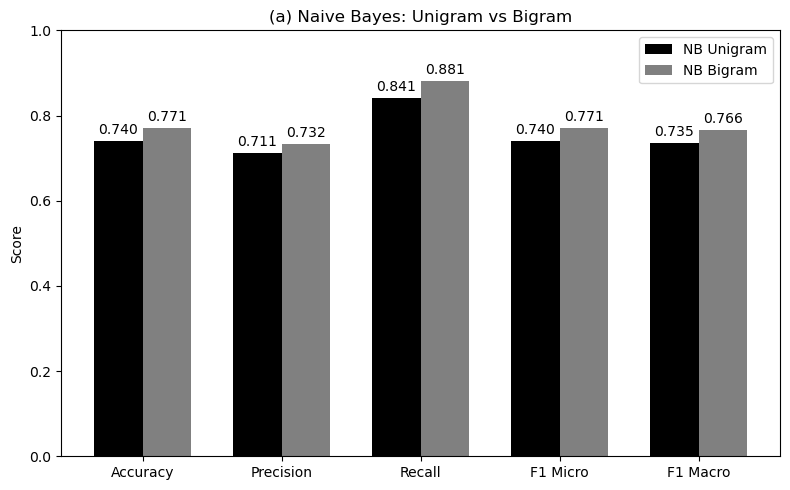

In [32]:
nb_unigram = [0.7399, 0.7110, 0.8412, 0.7399, 0.7351]
nb_bigram = [0.7707, 0.7322, 0.8807, 0.7707, 0.7658]

create_graph(nb_unigram, nb_bigram, 'NB Unigram', 'NB Bigram','(a) Naive Bayes: Unigram vs Bigram')

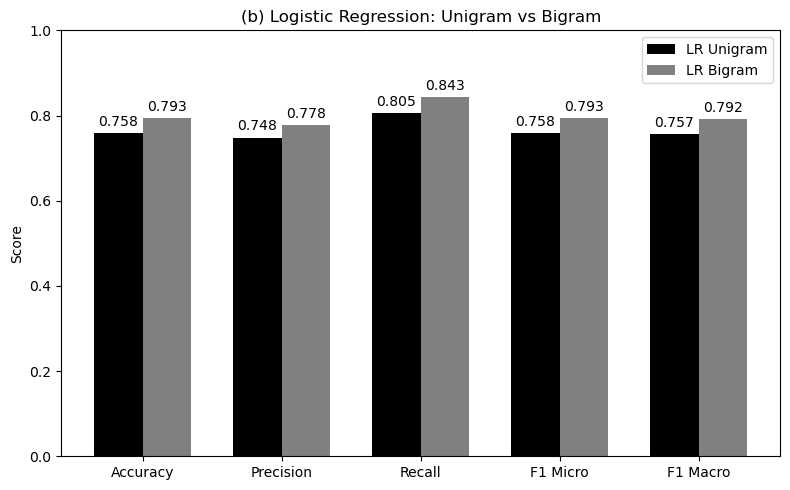

In [33]:
lr_unigram = [0.7581, 0.7483, 0.8054, 0.7581, 0.7566]
lr_bigram = [0.7933, 0.7779, 0.8429, 0.7933, 0.7919]

create_graph(lr_unigram, lr_bigram, 'LR Unigram', 'LR Bigram', '(b) Logistic Regression: Unigram vs Bigram')

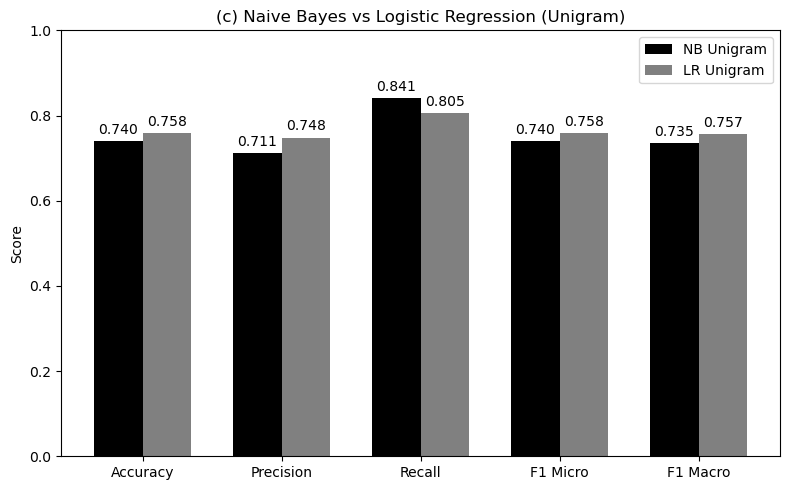

In [34]:
create_graph(nb_unigram, lr_unigram, 'NB Unigram', 'LR Unigram', '(c) Naive Bayes vs Logistic Regression (Unigram)')

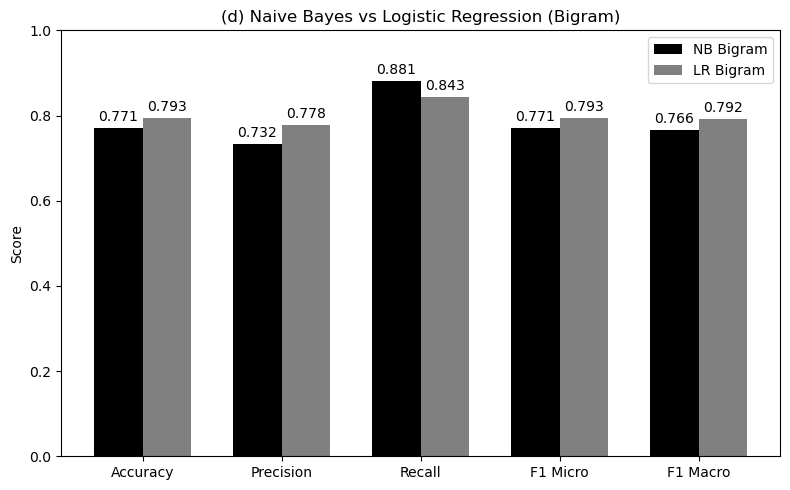

In [35]:
create_graph(nb_bigram, lr_bigram,'NB Bigram',  'LR Bigram', '(d)Naive Bayes vs Logistic Regression (Bigram)')

In [30]:
os.makedirs('saved_models', exist_ok=True)

# Saving vectorisers
joblib.dump(tfidf_u,  'saved_models/tfidf_u.pkl')
joblib.dump(tfidf_ub, 'saved_models/tfidf_ub.pkl')

# Saving trained models
joblib.dump(nb_u,  'saved_models/nb_u.pkl')
joblib.dump(nb_ub, 'saved_models/nb_ub.pkl')
joblib.dump(lr_u,  'saved_models/lr_u.pkl')
joblib.dump(lr_ub, 'saved_models/lr_ub.pkl')

# Saving test set
test_data = pd.DataFrame({'Sentences': X_test_text, 'Sentiment': y_test})
test_data.to_csv('saved_models/test_data.csv', index=False)

print("Saved: 2 vectorisers, 4 models, test data")

Saved: 2 vectorisers, 4 models, test data
